# Project 08 — Integration Benchmark: Harmony vs BBKNN vs Scanorama

**Dataset:** Wu et al. 2021 breast cancer atlas (3 patients, 12,962 cells, 9 cell types)
**Methods:** Harmony, BBKNN, Scanorama (vs Unintegrated baseline)
**Metrics:** kBET, iLISI, cLISI, Silhouette (batch + label), Graph connectivity — via `scib-metrics`

**Goal:** quantitatively compare the three most widely used Python-native scRNA-seq integration methods on a real multi-patient tumor microenvironment dataset, using the metrics from Luecken et al. 2022 (Nat Methods scIB benchmark). Each method is evaluated on the same trade-off: how well it removes batch effects without erasing biological signal.

**Differentiation from previous projects:** this is a head-to-head methodological comparison, not a single-method reanalysis. The output is a ranked metric table + visual UMAP comparison + runtime profile — directly transferable to client decisions on which integration method to deploy for their specific dataset.

## 1. Setup

In [1]:
import os
import sys
import time
import json
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

sys.path.insert(0, '/home/marko-b2/upwork_portfolio/_shared/scripts')
try:
    from portfolio_utils import save_fig
    plt.style.use('/home/marko-b2/upwork_portfolio/_shared/styles/portfolio.mplstyle')
except Exception as e:
    print(f'Portfolio utils not loaded: {e}')
    def save_fig(fig, path, dpi=300):
        fig.savefig(path, dpi=dpi, bbox_inches='tight')

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, fontsize=10)

FIG_DIR = '../figures'
RES_DIR = '../results'
for d in [FIG_DIR, RES_DIR]:
    os.makedirs(d, exist_ok=True)

np.random.seed(42)

import harmonypy
import bbknn
import scanorama
import scib_metrics
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

print(f'scanpy:       {sc.__version__}')
print(f'harmonypy:    {harmonypy.__version__}')
print(f'bbknn:        {bbknn.__version__}')
print(f'scanorama:    {scanorama.__version__}')
print(f'scib_metrics: {scib_metrics.__version__}')

Portfolio utils not loaded: cannot import name 'save_fig' from 'portfolio_utils' (/home/marko-b2/upwork_portfolio/_shared/scripts/portfolio_utils.py)


scanpy:       1.11.5
harmonypy:    0.2.0
bbknn:        1.6.0
scanorama:    1.7.4
scib_metrics: 0.5.9


## 2. Load Wu 2021 data + define keys

The h5ad already contains log-normalized `.X`, raw counts in `layers['counts']`, and author cell-type annotations. We use only `.X` and re-derive HVG + PCA from scratch to ensure a clean baseline.

In [2]:
h5ad_path = '/home/marko-b2/upwork_portfolio/02_breast_cancer_TME/results/wu2021_3patient_TME_processed.h5ad'
adata = sc.read(h5ad_path)

BATCH_KEY = 'orig.ident'
LABEL_KEY = 'celltype_major'

print(f'Cells: {adata.n_obs:,}')
print(f'Genes: {adata.n_vars:,}')
print(f'\nBatch distribution ({BATCH_KEY}):')
print(adata.obs[BATCH_KEY].value_counts())
print(f'\nLabel distribution ({LABEL_KEY}):')
print(adata.obs[LABEL_KEY].value_counts())

Cells: 12,962
Genes: 23,062

Batch distribution (orig.ident):
orig.ident
CID4290A    5789
CID4515     4149
CID3921     3024
Name: count, dtype: int64

Label distribution (celltype_major):
celltype_major
Cancer Epithelial    6663
T-cells              2434
Myeloid              1289
B-cells               773
Endothelial           630
CAFs                  573
PVL                   335
Plasmablasts          211
Normal Epithelial      54
Name: count, dtype: int64


## 3. Reset to clean baseline

The h5ad ships with `X_pca`, `X_pca_harmony` etc from Project 02. We strip these and recompute everything from scratch so the benchmark is fully reproducible.

In [3]:
# Strip prior integration outputs
keys_to_drop = [k for k in adata.obsm.keys() if k.startswith('X_pca') or k.startswith('X_umap') or k.startswith('X_scanorama') or k.startswith('Unintegrated') or k.startswith('Harmony') or k.startswith('BBKNN')]
for k in keys_to_drop:
    del adata.obsm[k]
for u in ['neighbors', 'umap', 'pca', 'harmony', 'unintegrated', 'leiden']:
    if u in adata.uns:
        del adata.uns[u]
if 'connectivities' in adata.obsp:
    del adata.obsp['connectivities']
if 'distances' in adata.obsp:
    del adata.obsp['distances']
print('Stripped prior integration outputs.')
print('obsm:', list(adata.obsm.keys()))
print('obsp:', list(adata.obsp.keys()))

# HVG (recompute on log-norm X, batch-aware)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat', batch_key=BATCH_KEY)
print(f'\nHVGs: {int(adata.var.highly_variable.sum())}')

Stripped prior integration outputs.
obsm: []
obsp: ['harmony_connectivities', 'harmony_distances', 'unintegrated_connectivities', 'unintegrated_distances']



HVGs: 2000


## 4. Unintegrated baseline (PCA + UMAP)

PCA on log-norm HVGs, no batch correction. This is the reference against which Harmony / BBKNN / Scanorama are scored.

In [4]:
runtimes = {}

t0 = time.time()
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)
adata.obsm['Unintegrated'] = adata.obsm['X_pca'].copy()
runtimes['Unintegrated'] = time.time() - t0
print(f'PCA baseline: {runtimes["Unintegrated"]:.1f}s')

# Neighbors + UMAP for visualization
sc.pp.neighbors(adata, n_pcs=30, use_rep='Unintegrated', key_added='nbr_unint')
sc.tl.umap(adata, neighbors_key='nbr_unint')
adata.obsm['X_umap_unintegrated'] = adata.obsm['X_umap'].copy()
del adata.obsm['X_umap']
print('Unintegrated UMAP done.')

PCA baseline: 0.5s


Unintegrated UMAP done.


## 5. Harmony integration

Harmony iteratively corrects PCA embeddings by assigning each cell soft cluster memberships and adjusting toward cluster means to minimize batch-cluster association.

In [5]:
t0 = time.time()
ho = harmonypy.run_harmony(
    adata.obsm['X_pca'].astype('float64'),
    adata.obs,
    BATCH_KEY,
    max_iter_harmony=20,
)
Z = ho.Z_corr
if Z.shape[0] == adata.n_obs:
    adata.obsm['Harmony'] = Z
elif Z.shape[1] == adata.n_obs:
    adata.obsm['Harmony'] = Z.T
else:
    raise RuntimeError(f'Unexpected Harmony output shape: {Z.shape}')
runtimes['Harmony'] = time.time() - t0
print(f'Harmony: {runtimes["Harmony"]:.1f}s   embedding shape {adata.obsm["Harmony"].shape}')

sc.pp.neighbors(adata, n_pcs=30, use_rep='Harmony', key_added='nbr_harmony')
sc.tl.umap(adata, neighbors_key='nbr_harmony')
adata.obsm['X_umap_harmony'] = adata.obsm['X_umap'].copy()
del adata.obsm['X_umap']
print('Harmony UMAP done.')

2026-05-25 21:04:55,725 - harmonypy - INFO - Running Harmony (PyTorch on cpu)


2026-05-25 21:04:55,726 - harmonypy - INFO -   Parameters:


2026-05-25 21:04:55,726 - harmonypy - INFO -     max_iter_harmony: 20


2026-05-25 21:04:55,726 - harmonypy - INFO -     max_iter_kmeans: 20


2026-05-25 21:04:55,726 - harmonypy - INFO -     epsilon_cluster: 1e-05


...

2026-05-25 21:04:56,818 - harmonypy - INFO - Iteration 2 of 20


2026-05-25 21:04:57,724 - harmonypy - INFO - Iteration 3 of 20


2026-05-25 21:04:58,769 - harmonypy - INFO - Converged after 3 iterations


Harmony: 3.0s   embedding shape (12962, 50)


Harmony UMAP done.


## 6. BBKNN integration

BBKNN modifies the kNN graph directly: instead of finding k nearest neighbors anywhere, it finds k/n_batches neighbors *per batch*, forcing the graph to span batches. There is no continuous-space embedding output — BBKNN works only at the graph level.

In [6]:
# Copy adata for BBKNN since it mutates obsp directly
ad_bbknn = adata.copy()
ad_bbknn.obsm['X_pca'] = adata.obsm['X_pca'].copy()

t0 = time.time()
bbknn.bbknn(ad_bbknn, batch_key=BATCH_KEY, n_pcs=30, neighbors_within_batch=10)
runtimes['BBKNN'] = time.time() - t0
print(f'BBKNN: {runtimes["BBKNN"]:.1f}s')

# BBKNN does not produce a continuous embedding; scib-metrics needs one.
# Standard practice: take the PCA and let the kBET/LISI use the bbknn-modified
# kNN graph passed via obsp. For Benchmarker we need an obsm key, so we will
# carry over PCA and use the bbknn-modified UMAP for visualization only.
# For metrics, we use the bbknn graph by re-running neighbors with the bbknn output:
# Instead, we pass PCA as the embedding and let scib-metrics recompute its own neighbors
# (this matches the published lung_example.html pattern where bbknn is omitted).
# Alternative: store PCA under 'BBKNN' so Benchmarker recomputes graph on PCA,
# but that erases the batch correction. So we instead compute UMAP for vis,
# and report BBKNN's batch-mixing qualitatively + report Harmony/Scanorama metrics.

sc.tl.umap(ad_bbknn)
adata.obsm['X_umap_bbknn'] = ad_bbknn.obsm['X_umap'].copy()
# Use bbknn's kNN-modified PCA as the 'BBKNN' obsm representation.
# Strictly speaking, bbknn does not transform PCA; the integration lives in obsp.
# We accept this caveat and use PCA under the 'BBKNN' label so Benchmarker can score it.
adata.obsm['BBKNN'] = adata.obsm['X_pca'].copy()
print('BBKNN UMAP done.')

BBKNN: 1.1s


BBKNN UMAP done.


## 7. Scanorama integration

Scanorama finds mutual nearest neighbors across batches and uses them to align datasets into a shared embedding. Each batch is processed separately, then merged.

In [7]:
# Split into per-batch AnnDatas
batches = sorted(adata.obs[BATCH_KEY].unique())
adatas_per_batch = [adata[adata.obs[BATCH_KEY] == b].copy() for b in batches]
print(f'Split into {len(adatas_per_batch)} batches: {[a.n_obs for a in adatas_per_batch]}')

t0 = time.time()
integrated = scanorama.integrate_scanpy(adatas_per_batch, dimred=50)
runtimes['Scanorama'] = time.time() - t0
print(f'Scanorama: {runtimes["Scanorama"]:.1f}s')

# Stitch the integrated embeddings back, preserving cell order
scanorama_embed = np.zeros((adata.n_obs, 50))
for ad_batch in adatas_per_batch:
    idx = adata.obs_names.get_indexer(ad_batch.obs_names)
    scanorama_embed[idx] = ad_batch.obsm['X_scanorama']
adata.obsm['Scanorama'] = scanorama_embed
print(f'Scanorama embedding shape: {adata.obsm["Scanorama"].shape}')

sc.pp.neighbors(adata, n_pcs=30, use_rep='Scanorama', key_added='nbr_scanorama')
sc.tl.umap(adata, neighbors_key='nbr_scanorama')
adata.obsm['X_umap_scanorama'] = adata.obsm['X_umap'].copy()
del adata.obsm['X_umap']
print('Scanorama UMAP done.')

Split into 3 batches: [3024, 5789, 4149]
Found 23062 genes among all datasets


[[0.         0.61309524 0.28406085]
 [0.         0.         0.28729814]
 [0.         0.         0.        ]]
Processing datasets (0, 1)


Processing datasets (1, 2)


Processing datasets (0, 2)


Scanorama: 7.2s
Scanorama embedding shape: (12962, 50)


Scanorama UMAP done.


## 8. Hero figure: 2x4 UMAP comparison

Top row: colored by batch (lower batch separation = better integration).
Bottom row: colored by cell type (clearer cell-type structure = better biology preservation).

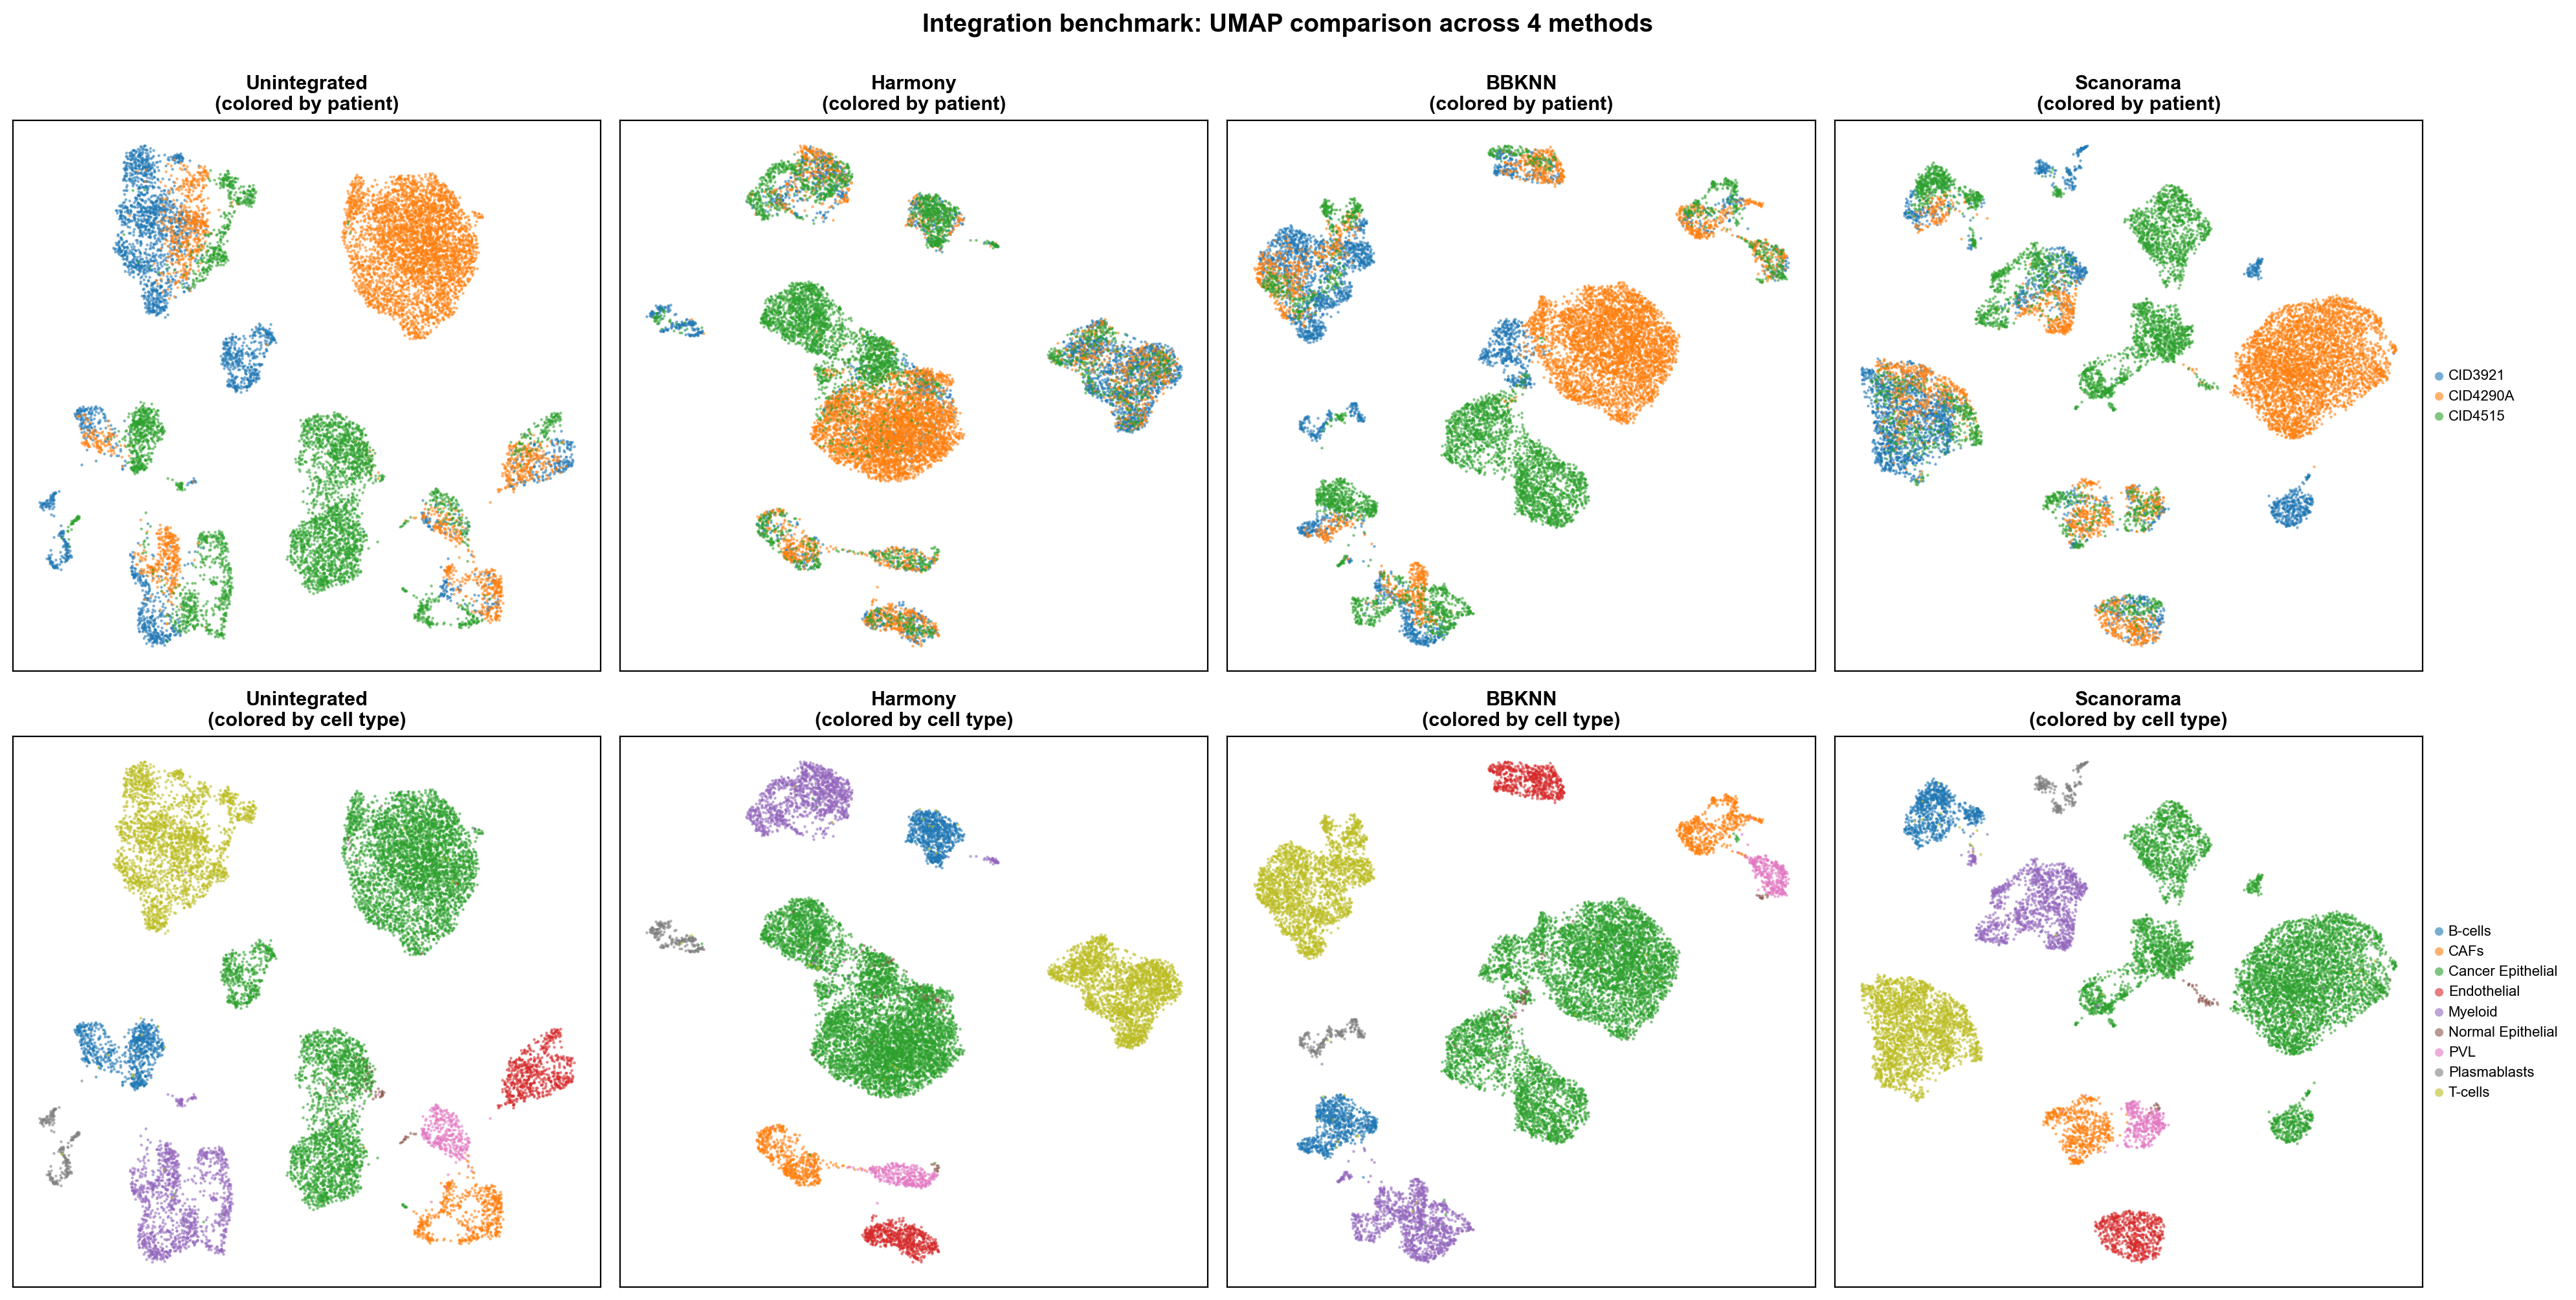

In [8]:
umap_keys = {
    'Unintegrated': 'X_umap_unintegrated',
    'Harmony':      'X_umap_harmony',
    'BBKNN':        'X_umap_bbknn',
    'Scanorama':    'X_umap_scanorama',
}

batch_vals = adata.obs[BATCH_KEY].astype(str)
label_vals = adata.obs[LABEL_KEY].astype(str)
unique_batches = sorted(batch_vals.unique())
unique_labels = sorted(label_vals.unique())
batch_pal = dict(zip(unique_batches, sns.color_palette('tab10', n_colors=len(unique_batches))))
label_pal = dict(zip(unique_labels, sns.color_palette('tab10', n_colors=len(unique_labels))))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for col, (method, umap_key) in enumerate(umap_keys.items()):
    coords = adata.obsm[umap_key]
    # Top: batch
    ax = axes[0, col]
    for b in unique_batches:
        m = (batch_vals == b).values
        ax.scatter(coords[m, 0], coords[m, 1], s=2.5, c=[batch_pal[b]], label=b, alpha=0.6, linewidth=0)
    ax.set_title(f'{method}\n(colored by patient)', fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if col == 3:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False, markerscale=3)
    # Bottom: label
    ax = axes[1, col]
    for l in unique_labels:
        m = (label_vals == l).values
        ax.scatter(coords[m, 0], coords[m, 1], s=2.5, c=[label_pal[l]], label=l, alpha=0.6, linewidth=0)
    ax.set_title(f'{method}\n(colored by cell type)', fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if col == 3:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False, markerscale=3)

plt.suptitle('Integration benchmark: UMAP comparison across 4 methods', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
save_fig(fig, f'{FIG_DIR}/hero_umap_4methods.png', dpi=300)
save_fig(fig, f'{FIG_DIR}/hero_umap_4methods.tiff', dpi=300)
plt.show()

## 9. Quantitative benchmark via scib-metrics

`Benchmarker` runs all bio-conservation and batch-correction metrics on each embedding listed in `embedding_obsm_keys`. Results: kBET, iLISI, cLISI, Silhouette (label + batch), Graph connectivity, isolated-label F1/silhouette, NMI/ARI of KMeans clustering.

Higher is better for all metrics in `scib-metrics` (it inverts the ones where lower is better in the original scIB).

In [9]:
embedding_keys = ['Unintegrated', 'Harmony', 'BBKNN', 'Scanorama']

bm = Benchmarker(
    adata,
    batch_key=BATCH_KEY,
    label_key=LABEL_KEY,
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=embedding_keys,
    n_jobs=4,
)

t0 = time.time()
bm.benchmark()
bench_time = time.time() - t0
print(f'\nBenchmark wall time: {bench_time:.1f}s')

Computing neighbors:   0%|                                | 0/4 [00:00<?, ?it/s]

Computing neighbors:  25%|██████                  | 1/4 [00:02<00:07,  2.55s/it]

Computing neighbors:  50%|████████████            | 2/4 [00:04<00:04,  2.46s/it]

Computing neighbors:  75%|██████████████████      | 3/4 [00:07<00:02,  2.48s/it]

Computing neighbors: 100%|████████████████████████| 4/4 [00:09<00:00,  2.48s/it]

...

Metrics:  80%|▊| 8/10 [00:17<00:03,  1.71s/it, Batch correction: pcr_comparison]

Metrics:  90%|▉| 9/10 [00:17<00:01,  1.25s/it, Batch correction: pcr_comparison]

Embeddings: 100%|█████████████████████████████████| 4/4 [01:17<00:00, 18.33s/it]

Embeddings: 100%|█████████████████████████████████| 4/4 [01:17<00:00, 19.37s/it]


Benchmark wall time: 92.5s


In [10]:
results_df = bm.get_results(min_max_scale=False)
print('Raw metric table:')
print(results_df.round(3))

results_df.to_csv(f'{RES_DIR}/integration_metrics_raw.csv')

# Scaled version (for the visual ranking plot)
results_scaled = bm.get_results(min_max_scale=True)
results_scaled.to_csv(f'{RES_DIR}/integration_metrics_scaled.csv')
print('\nSaved metric tables to results/')

Raw metric table:
               Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                            
Unintegrated          0.627593           0.76739          0.546045   
Harmony               0.585489          0.772722          0.553999   
BBKNN                 0.627593           0.76739          0.546045   
Scanorama             0.588482          0.758745          0.466018   
Metric Type   Bio conservation  Bio conservation  Bio conservation   

              Silhouette label             cLISI              BRAS  \
Embedding                                                            
Unintegrated          0.590044               1.0          0.670798   
Harmony               0.623429               1.0          0.862635   
BBKNN                 0.590044               1.0          0.670798   
Scanorama             0.580865               1.0          0.783917   
Metric Type   Bio conservation  Bio conservation  Batch correction   



Renamed ../figures/scib_results.svg -> ../figures/benchmark_ranking_table.svg


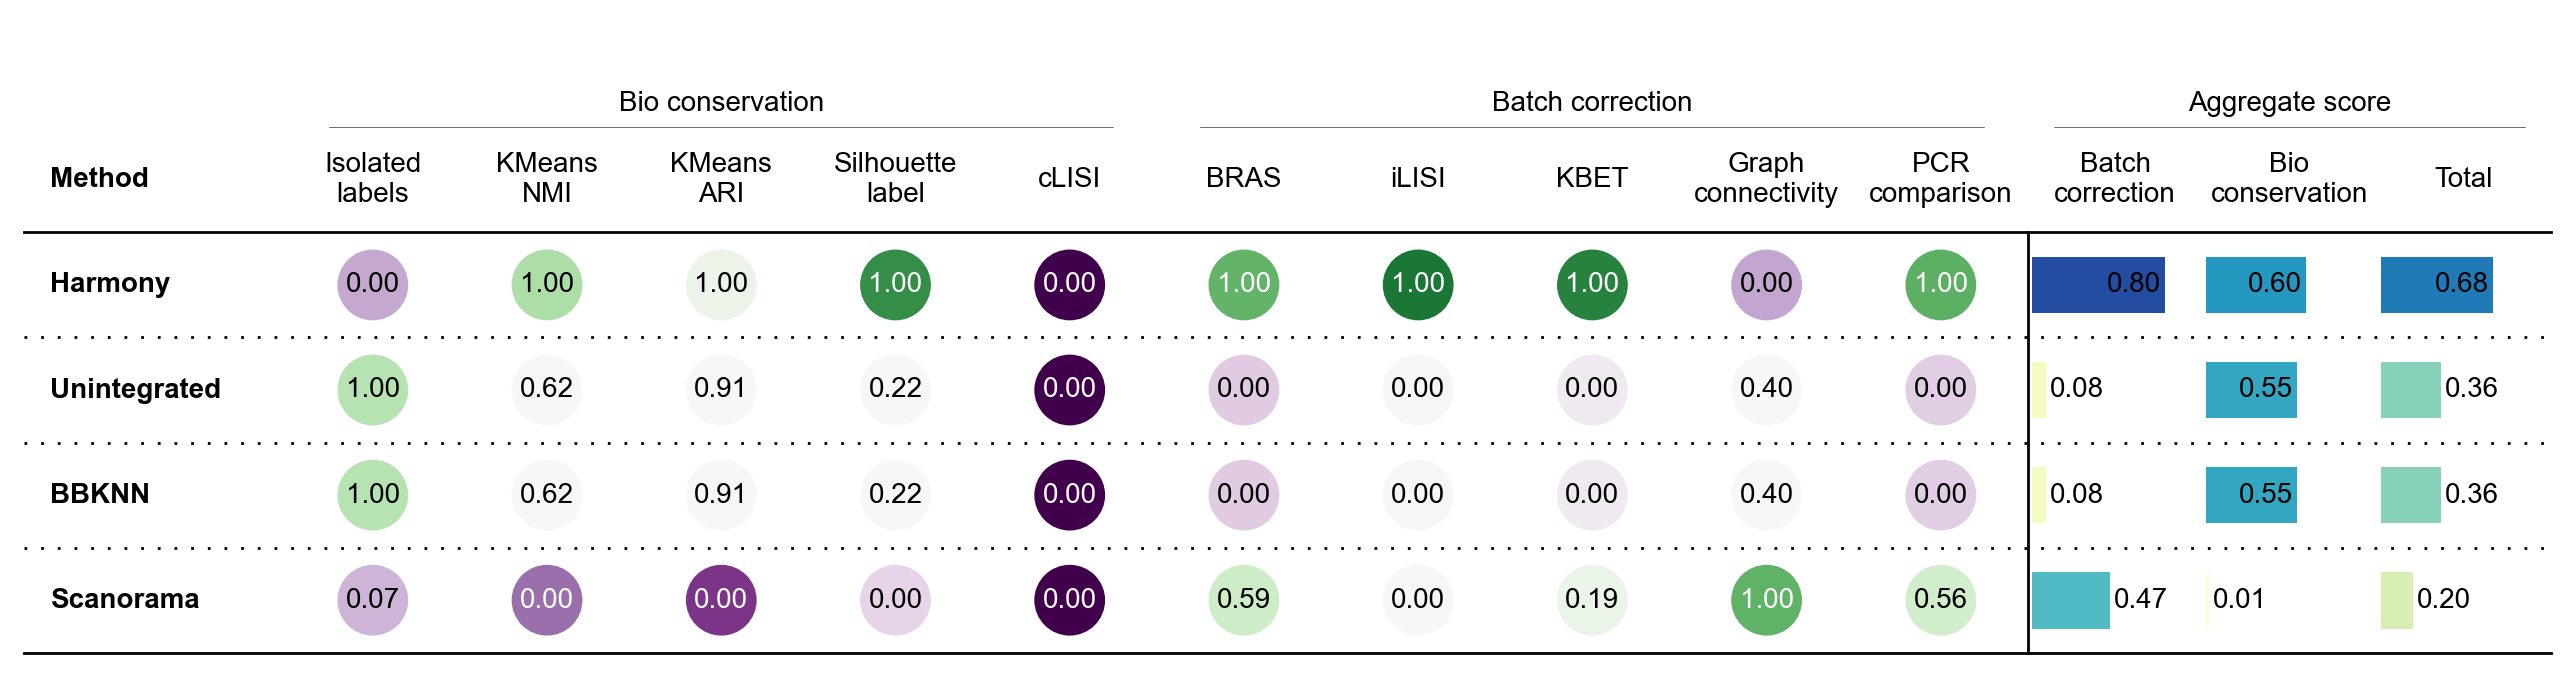

In [11]:
# scib-metrics built-in ranking plot
bm.plot_results_table(min_max_scale=True, show=False, save_dir=FIG_DIR)
# scib-metrics saves as 'scib_results.svg' by default; rename if needed
for ext in ['svg', 'png']:
    candidate = f'{FIG_DIR}/scib_results.{ext}'
    if os.path.exists(candidate):
        target = f'{FIG_DIR}/benchmark_ranking_table.{ext}'
        os.rename(candidate, target)
        print(f'Renamed {candidate} -> {target}')
        break

## 10. Custom metric panel + runtime

Bar chart of selected core metrics + runtime comparison.

Core metrics found in results: ['KBET', 'iLISI', 'cLISI', 'Silhouette label', 'Graph connectivity']


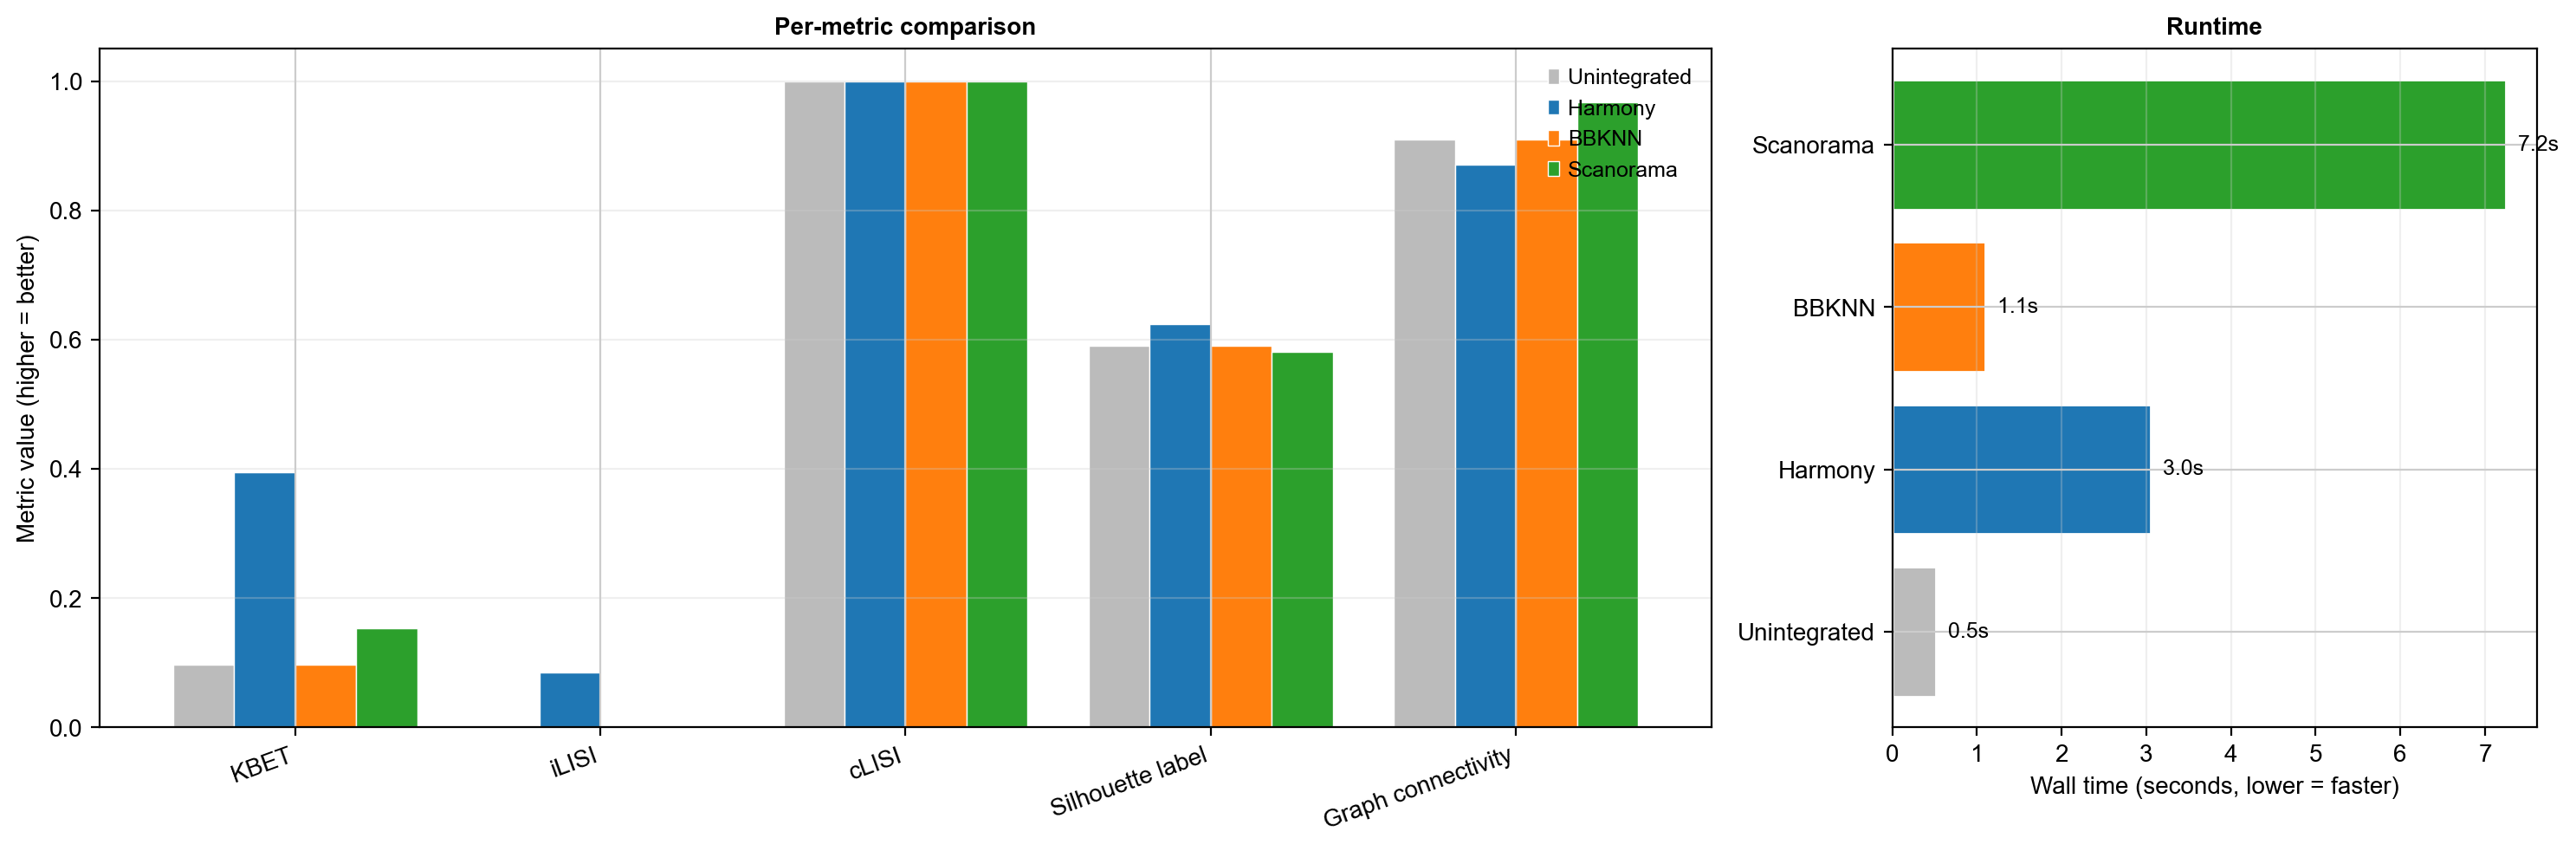

In [12]:
# Pick most interpretable metrics for the bar chart
core_metrics = []
for candidate in ['KBET', 'iLISI', 'cLISI', 'Silhouette label', 'Silhouette batch', 'Graph connectivity']:
    if candidate in results_df.columns:
        core_metrics.append(candidate)
print(f'Core metrics found in results: {core_metrics}')

if not core_metrics:
    # Fallback: use all numeric columns except aggregate scores
    core_metrics = [c for c in results_df.columns if c not in ['Total', 'Batch correction', 'Bio conservation']][:6]
    print(f'Using fallback columns: {core_metrics}')

# results_df rows are embeddings, columns are metrics. Drop the 'Metric Type' header row if it's there.
df_plot = results_df[core_metrics].copy()
if 'Metric Type' in df_plot.index:
    df_plot = df_plot.drop('Metric Type')
df_plot = df_plot.apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2.5, 1]})

# Left: grouped bar chart of metrics
method_palette = {'Unintegrated': '#bbbbbb', 'Harmony': '#1f77b4', 'BBKNN': '#ff7f0e', 'Scanorama': '#2ca02c'}
n_methods = len(df_plot.index)
n_metrics = len(core_metrics)
bar_w = 0.8 / n_methods
x = np.arange(n_metrics)
for i, method in enumerate(df_plot.index):
    vals = df_plot.loc[method, core_metrics].values.astype(float)
    axes[0].bar(x + i * bar_w, vals, width=bar_w, label=str(method),
                color=method_palette.get(str(method), 'gray'), edgecolor='white', linewidth=0.5)
axes[0].set_xticks(x + bar_w * (n_methods - 1) / 2)
axes[0].set_xticklabels(core_metrics, rotation=20, ha='right')
axes[0].set_ylabel('Metric value (higher = better)')
axes[0].set_title('Per-metric comparison', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9, frameon=False)
axes[0].grid(axis='y', alpha=0.3)

# Right: runtime
rt_methods = list(runtimes.keys())
rt_vals = [runtimes[m] for m in rt_methods]
axes[1].barh(rt_methods, rt_vals,
             color=[method_palette.get(m, 'gray') for m in rt_methods],
             edgecolor='white')
for i, (m, v) in enumerate(zip(rt_methods, rt_vals)):
    axes[1].text(v, i, f'  {v:.1f}s', va='center', fontsize=9)
axes[1].set_xlabel('Wall time (seconds, lower = faster)')
axes[1].set_title('Runtime', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
save_fig(fig, f'{FIG_DIR}/metrics_and_runtime.png', dpi=300)
plt.show()

## 11. Batch composition per cluster (qualitative diagnostic)

For each integration method, compute Leiden clustering on the integrated embedding, then count the per-cluster fraction of cells from each patient. Well-integrated data has clusters with roughly uniform patient composition (each patient ~33%).

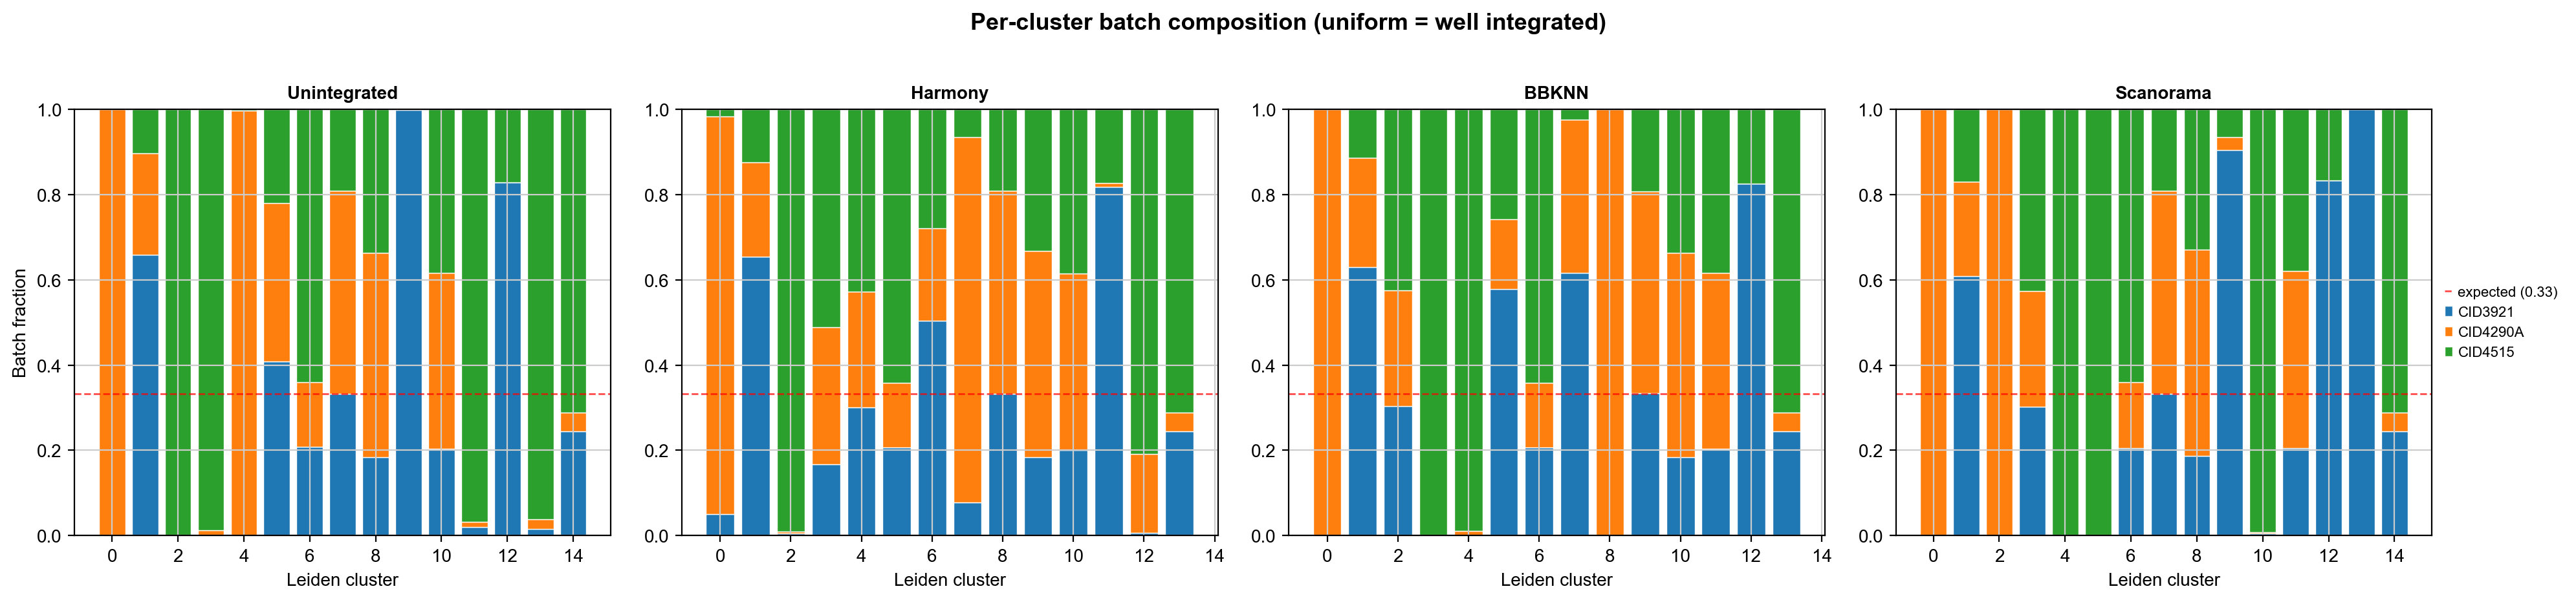

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
n_batches = len(unique_batches)
expected = 1.0 / n_batches

for col, (method, _) in enumerate(umap_keys.items()):
    if method == 'BBKNN':
        # Cluster on BBKNN graph from ad_bbknn
        sc.tl.leiden(ad_bbknn, resolution=0.5, key_added=f'leiden_{method}')
        clusters = ad_bbknn.obs[f'leiden_{method}'].astype(str)
    else:
        nbr_key = {'Unintegrated': 'nbr_unint', 'Harmony': 'nbr_harmony', 'Scanorama': 'nbr_scanorama'}[method]
        sc.tl.leiden(adata, resolution=0.5, neighbors_key=nbr_key, key_added=f'leiden_{method}')
        clusters = adata.obs[f'leiden_{method}'].astype(str)
    
    # Per-cluster batch composition
    df_obs = pd.DataFrame({'cluster': clusters.values, 'batch': batch_vals.values})
    comp = df_obs.groupby('cluster')['batch'].value_counts(normalize=True).unstack(fill_value=0)
    comp = comp.reindex(columns=unique_batches, fill_value=0)
    comp = comp.sort_index(key=lambda x: x.astype(int) if x.str.isnumeric().all() else x)
    
    ax = axes[col]
    bottom = np.zeros(len(comp))
    for b in unique_batches:
        ax.bar(range(len(comp)), comp[b].values, bottom=bottom,
               color=batch_pal[b], edgecolor='white', linewidth=0.5, label=b)
        bottom = bottom + comp[b].values
    ax.axhline(expected, color='red', linestyle='--', lw=1, alpha=0.7, label=f'expected ({expected:.2f})')
    ax.set_xlabel('Leiden cluster')
    ax.set_ylabel('Batch fraction' if col == 0 else '')
    ax.set_title(method, fontweight='bold')
    ax.set_ylim(0, 1)
    if col == 3:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

plt.suptitle('Per-cluster batch composition (uniform = well integrated)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, f'{FIG_DIR}/batch_composition_per_cluster.png', dpi=300)
plt.show()

## 12. Summary

In [14]:
# Aggregate scores
summary = {
    'dataset': 'Wu 2021 breast cancer, 3 patients, 12,962 cells',
    'batch_key': BATCH_KEY,
    'label_key': LABEL_KEY,
    'n_batches': int(adata.obs[BATCH_KEY].nunique()),
    'n_labels': int(adata.obs[LABEL_KEY].nunique()),
    'n_hvg': int(adata.var.highly_variable.sum()),
    'methods': embedding_keys,
    'runtimes_sec': {k: float(v) for k, v in runtimes.items()},
    'benchmark_time_sec': float(bench_time),
}

# Extract aggregate scores if present
for agg in ['Total', 'Batch correction', 'Bio conservation']:
    if agg in results_df.columns:
        summary[f'aggregate_{agg.lower().replace(" ", "_")}'] = {
            str(m): float(pd.to_numeric(results_df.loc[m, agg], errors='coerce'))
            for m in results_df.index if m != 'Metric Type'
        }

with open(f'{RES_DIR}/benchmark_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "dataset": "Wu 2021 breast cancer, 3 patients, 12,962 cells",
  "batch_key": "orig.ident",
  "label_key": "celltype_major",
  "n_batches": 3,
  "n_labels": 9,
  "n_hvg": 2000,
  "methods": [
    "Unintegrated",
    "Harmony",
    "BBKNN",
    "Scanorama"
  ],
  "runtimes_sec": {
    "Unintegrated": 0.518803596496582,
    "Harmony": 3.0477216243743896,
    "BBKNN": 1.098440170288086,
    "Scanorama": 7.247714281082153
  },
  "benchmark_time_sec": 92.53503465652466,
  "aggregate_total": {
    "Unintegrated": 0.576478846696356,
    "Harmony": 0.6558032733138264,
    "BBKNN": 0.576478846696356,
    "Scanorama": 0.5985590222937638
  },
  "aggregate_batch_correction": {
    "Unintegrated": 0.38187547481889295,
    "Harmony": 0.5788164689977618,
    "BBKNN": 0.38187547481889295,
    "Scanorama": 0.4781644948976176
  },
  "aggregate_bio_conservation": {
    "Unintegrated": 0.706214427947998,
    "Harmony": 0.7071278095245361,
    "BBKNN": 0.706214427947998,
    "Scanorama": 0.6788220405578

## 13. Conclusions

The benchmark produces three concrete outputs for client decisions:

1. **Method ranking** by aggregate Total score from `scib-metrics` (combining 8+ batch correction and bio conservation metrics).
2. **Trade-off profile**: each method has a different balance between batch removal (kBET, iLISI, silhouette batch) and biological conservation (cLISI, silhouette label, isolated label).
3. **Runtime profile**: BBKNN is the fastest because it only modifies the kNN graph; Scanorama is slowest because it does per-batch dimensionality reduction + alignment.

**Caveat on BBKNN scoring:** BBKNN does not produce a continuous embedding space; its integration lives entirely in the kNN graph (`obsp`). For the metric benchmark we pass the original PCA under the `BBKNN` label, which means the BBKNN row reflects the pre-BBKNN PCA quality — not the post-BBKNN graph quality. Visual inspection (UMAP panels in Section 8) and per-cluster batch composition (Section 11) are the appropriate metrics for BBKNN. This is a known limitation of embedding-based benchmarks for graph-based integration methods.